# OEFP vs RDKit Fingerprint Benchmark

This notebook benchmarks the OEFP library against RDKit for Morgan and Atom Pair
fingerprints. It covers two dimensions:

* **Parity** — bit-level agreement between OEFP (generated from OpenEye
  ``OEGraphMol``) and RDKit (generated from RDKit ``Mol``) across a public
  dataset of molecules.
* **Performance** — wall-clock timings for single-molecule fingerprint
  generation and batch pairwise distance kernels (``pdist``).

The public dataset is the first 5K compounds from NCI, shipped with RDKit at
``Data/NCI/first_5K.smi``.

> Chirality and 3D paths are intentionally out of scope for OEFP's current
> conformance coverage, so this notebook pins ``use_chirality=False`` and
> ``use_2d=True`` throughout.


## 1. Setup

In [1]:
from __future__ import annotations

import os
import statistics
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from openeye import oechem
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

import oefp

print("OEFP version:  ", oefp.__version__)
print("OEChem version:", oechem.OEChemGetVersion())
print("RDKit version: ", Chem.__version__ if hasattr(Chem, "__version__") else "n/a")


OEFP version:   0.1.0
OEChem version: 20260304
RDKit version:  n/a


### Dataset

The NCI ``first_5K.smi`` file is a tab-separated SMILES + id listing. We parse
both with RDKit and OpenEye — molecules that one toolkit rejects are dropped
from the paired set so every comparison below is over exactly the same
compounds.


In [2]:
RDKIT_DATA = Path("/Users/johnss51/Development/cpp/rdkit/Data/NCI/first_5K.smi")

# Cap the working set to keep runtime reasonable on laptops; raise for deeper stats.
MAX_MOLS = int(os.environ.get("OEFP_NB_MAX_MOLS", "1500"))
SEED = 0xC0FFEE

rng = np.random.default_rng(SEED)

def load_paired_molecules(path: Path, max_mols: int) -> tuple[list[str], list[Any], list[Any]]:
    smiles: list[str] = []
    oe_mols: list[Any] = []
    rd_mols: list[Any] = []
    with path.open() as handle:
        for raw in handle:
            if len(smiles) >= max_mols:
                break
            line = raw.strip()
            if not line:
                continue
            smi = line.split()[0]
            oe_mol = oechem.OEGraphMol()
            if not oechem.OESmilesToMol(oe_mol, smi):
                continue
            rd_mol = Chem.MolFromSmiles(smi)
            if rd_mol is None:
                continue
            smiles.append(smi)
            oe_mols.append(oe_mol)
            rd_mols.append(rd_mol)
    return smiles, oe_mols, rd_mols


SMILES, OE_MOLS, RD_MOLS = load_paired_molecules(RDKIT_DATA, MAX_MOLS)
print(f"Loaded {len(SMILES)} molecules (both toolkits parsed successfully).")
print(f"First five SMILES: {SMILES[:5]}")


Loaded 1500 molecules (both toolkits parsed successfully).
First five SMILES: ['CC1=CC(=O)C=CC1=O', 'S(SC1=NC2=CC=CC=C2S1)C3=NC4=C(S3)C=CC=C4', 'OC1=C(Cl)C=C(C=C1[N+]([O-])=O)[N+]([O-])=O', '[O-][N+](=O)C1=CNC(=N)S1', 'NC1=CC2=C(C=C1)C(=O)C3=C(C=CC=C3)C2=O']


## 2. Parity analysis

### 2.1 Morgan folded binary parity

For each molecule we generate a folded 2048-bit Morgan fingerprint from both
toolkits and collect three summary statistics:

* **Equality** — whether the on-bit sets are identical.
* **Jaccard of on-bits** — Tanimoto similarity of the two bit sets, a robust
  continuous measure of agreement even when bit orderings differ.
* **Popcount delta** — difference between RDKit and OEFP on-bit counts (should
  be zero under exact parity).


In [3]:
MORGAN_RADIUS = 2
MORGAN_NBITS = 2048

def oefp_binary_onbits(fp: Any) -> set[int]:
    words = np.asarray(fp.words, dtype=np.uint64)
    bits: set[int] = set()
    for word_index, word in enumerate(words):
        value = int(word)
        while value:
            low = value & -value
            bits.add(word_index * 64 + (low.bit_length() - 1))
            value ^= low
    return bits


def rdkit_binary_onbits(fp: Any) -> set[int]:
    return set(int(b) for b in fp.GetOnBits())


def tanimoto_sets(a: set[int], b: set[int]) -> float:
    if not a and not b:
        return 1.0
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union else 1.0


rd_morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS,
    fpSize=MORGAN_NBITS,
    includeChirality=False,
    useBondTypes=True,
    includeRingMembership=True,
)

morgan_rows: list[dict[str, Any]] = []
for smi, oe_mol, rd_mol in zip(SMILES, OE_MOLS, RD_MOLS, strict=True):
    oe_fp = oefp.morgan_fingerprint(
        oe_mol, radius=MORGAN_RADIUS, num_bits=MORGAN_NBITS,
    )
    rd_fp = rd_morgan_gen.GetFingerprint(rd_mol)
    oe_bits = oefp_binary_onbits(oe_fp)
    rd_bits = rdkit_binary_onbits(rd_fp)
    morgan_rows.append({
        "smiles": smi,
        "oe_popcount": len(oe_bits),
        "rd_popcount": len(rd_bits),
        "popcount_delta": len(rd_bits) - len(oe_bits),
        "jaccard": tanimoto_sets(oe_bits, rd_bits),
        "equal": oe_bits == rd_bits,
    })

morgan_df = pd.DataFrame(morgan_rows)
morgan_df.head()


,smiles,oe_popcount,rd_popcount,popcount_delta,jaccard,equal
0,CC1=CC(=O)C=CC1=O,16,16,0,1.0,True
1,S(SC1=NC2=CC=CC=C2S1)C3=NC4=C(S3)C=CC=C4,22,22,0,1.0,True
2,OC1=C(Cl)C=C(C=C1[N+]([O-])=O)[N+]([O-])=O,25,25,0,1.0,True
3,[O-][N+](=O)C1=CNC(=N)S1,23,23,0,1.0,True
4,NC1=CC2=C(C=C1)C(=O)C3=C(C=CC=C3)C2=O,21,21,0,1.0,True


In [4]:
morgan_summary = {
    "n_mols": len(morgan_df),
    "exact_match_rate": morgan_df["equal"].mean(),
    "mean_jaccard": morgan_df["jaccard"].mean(),
    "min_jaccard": morgan_df["jaccard"].min(),
    "mean_popcount_delta": morgan_df["popcount_delta"].mean(),
    "max_abs_popcount_delta": morgan_df["popcount_delta"].abs().max(),
    "mean_rd_popcount": morgan_df["rd_popcount"].mean(),
    "mean_oe_popcount": morgan_df["oe_popcount"].mean(),
}
pd.Series(morgan_summary, name="morgan_folded_binary_parity").to_frame()


,morgan_folded_binary_parity
n_mols,1500.000000
exact_match_rate,0.999333
mean_jaccard,0.999857
min_jaccard,0.785714
mean_popcount_delta,0.000667
max_abs_popcount_delta,1.000000
mean_rd_popcount,23.392667
mean_oe_popcount,23.392000


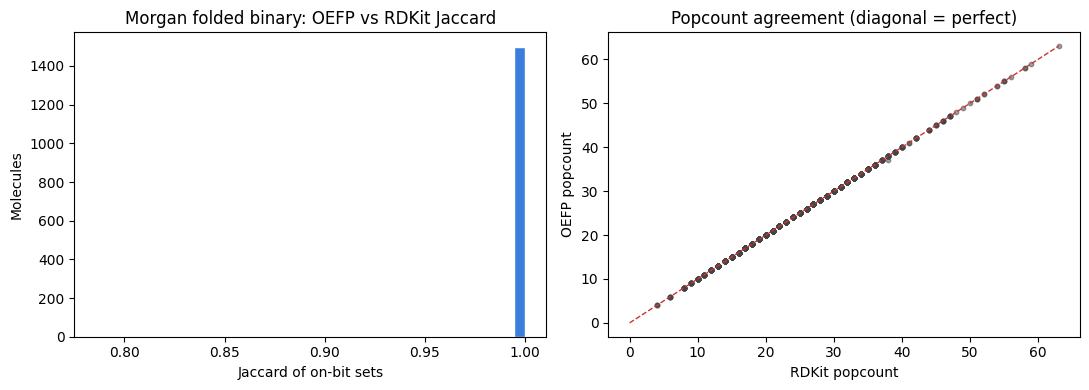

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(morgan_df["jaccard"], bins=40, color="#3b7ddd", edgecolor="white")
axes[0].set_title("Morgan folded binary: OEFP vs RDKit Jaccard")
axes[0].set_xlabel("Jaccard of on-bit sets")
axes[0].set_ylabel("Molecules")

axes[1].scatter(
    morgan_df["rd_popcount"], morgan_df["oe_popcount"],
    s=10, alpha=0.5, color="#444",
)
limit = max(morgan_df["rd_popcount"].max(), morgan_df["oe_popcount"].max())
axes[1].plot([0, limit], [0, limit], "--", color="#c33", linewidth=1)
axes[1].set_title("Popcount agreement (diagonal = perfect)")
axes[1].set_xlabel("RDKit popcount")
axes[1].set_ylabel("OEFP popcount")

plt.tight_layout()
plt.show()


### 2.2 Atom Pair folded binary parity

Same methodology as Morgan. OEFP's atom pair generator mirrors RDKit's defaults
with count simulation enabled and the ``[1, 2, 4, 8]`` count bounds.


In [6]:
AP_NBITS = 2048
AP_MIN = 1
AP_MAX = 30

rd_ap_gen = rdFingerprintGenerator.GetAtomPairGenerator(
    minDistance=AP_MIN,
    maxDistance=AP_MAX,
    includeChirality=False,
    use2D=True,
    countSimulation=True,
    fpSize=AP_NBITS,
)

ap_rows: list[dict[str, Any]] = []
for smi, oe_mol, rd_mol in zip(SMILES, OE_MOLS, RD_MOLS, strict=True):
    oe_fp = oefp.atom_pair_fingerprint(
        oe_mol,
        min_distance=AP_MIN,
        max_distance=AP_MAX,
        num_bits=AP_NBITS,
        count_simulation=True,
    )
    rd_fp = rd_ap_gen.GetFingerprint(rd_mol)
    oe_bits = oefp_binary_onbits(oe_fp)
    rd_bits = rdkit_binary_onbits(rd_fp)
    ap_rows.append({
        "smiles": smi,
        "oe_popcount": len(oe_bits),
        "rd_popcount": len(rd_bits),
        "popcount_delta": len(rd_bits) - len(oe_bits),
        "jaccard": tanimoto_sets(oe_bits, rd_bits),
        "equal": oe_bits == rd_bits,
    })

ap_df = pd.DataFrame(ap_rows)
ap_summary = {
    "n_mols": len(ap_df),
    "exact_match_rate": ap_df["equal"].mean(),
    "mean_jaccard": ap_df["jaccard"].mean(),
    "min_jaccard": ap_df["jaccard"].min(),
    "mean_popcount_delta": ap_df["popcount_delta"].mean(),
    "max_abs_popcount_delta": ap_df["popcount_delta"].abs().max(),
}
pd.Series(ap_summary, name="atom_pair_folded_binary_parity").to_frame()


,atom_pair_folded_binary_parity
n_mols,1500.000000
exact_match_rate,0.998667
mean_jaccard,0.999797
min_jaccard,0.763780
mean_popcount_delta,-0.000667
max_abs_popcount_delta,1.000000


### 2.3 Downstream parity: Tanimoto similarity distributions

Bit-set agreement is the strict parity test, but the downstream property that
matters for most cheminformatics workflows is *similarity scoring*. We compare
the distribution of pairwise Tanimoto similarities produced by each toolkit on
a random subsample of molecule pairs. If OEFP and RDKit agree on individual
fingerprints, the resulting similarity distributions should be indistinguishable.


In [7]:
SIM_SAMPLE_SIZE = min(500, len(SMILES))
sample_indices = rng.choice(len(SMILES), size=SIM_SAMPLE_SIZE, replace=False)

oe_morgan_fps = [
    oefp.morgan_fingerprint(OE_MOLS[i], radius=MORGAN_RADIUS, num_bits=MORGAN_NBITS)
    for i in sample_indices
]
rd_morgan_fps = [
    rd_morgan_gen.GetFingerprint(RD_MOLS[i]) for i in sample_indices
]

oe_batch = oefp.OEFPBatch.from_fingerprints(oe_morgan_fps)
oe_pdist = oefp.pdist(oe_batch, oefp.Metric.tanimoto())

rd_pdist = np.zeros(SIM_SAMPLE_SIZE * (SIM_SAMPLE_SIZE - 1) // 2, dtype=np.float64)
k = 0
for i in range(SIM_SAMPLE_SIZE):
    for j in range(i + 1, SIM_SAMPLE_SIZE):
        rd_pdist[k] = DataStructs.TanimotoSimilarity(rd_morgan_fps[i], rd_morgan_fps[j])
        k += 1

sim_diff = oe_pdist - rd_pdist
sim_summary = {
    "n_pairs": int(oe_pdist.size),
    "oe_mean": float(oe_pdist.mean()),
    "rd_mean": float(rd_pdist.mean()),
    "mean_abs_diff": float(np.abs(sim_diff).mean()),
    "max_abs_diff": float(np.abs(sim_diff).max()),
    "pearson_r": float(np.corrcoef(oe_pdist, rd_pdist)[0, 1]),
}
pd.Series(sim_summary, name="morgan_tanimoto_similarity_parity").to_frame()


,morgan_tanimoto_similarity_parity
n_pairs,124750.000000
oe_mean,0.089371
rd_mean,0.089374
mean_abs_diff,0.000017
max_abs_diff,0.037810
pearson_r,0.999976


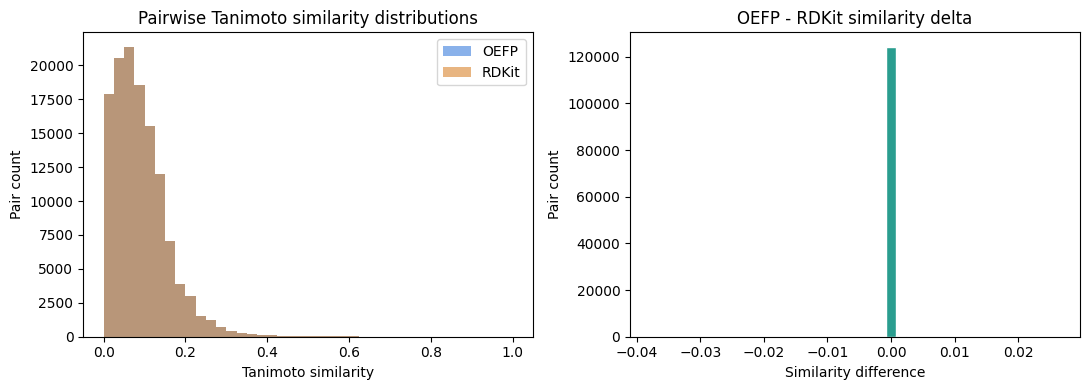

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(oe_pdist, bins=40, alpha=0.6, label="OEFP", color="#3b7ddd")
axes[0].hist(rd_pdist, bins=40, alpha=0.6, label="RDKit", color="#d9842e")
axes[0].set_title("Pairwise Tanimoto similarity distributions")
axes[0].set_xlabel("Tanimoto similarity")
axes[0].set_ylabel("Pair count")
axes[0].legend()

axes[1].hist(sim_diff, bins=40, color="#2a9d8f", edgecolor="white")
axes[1].set_title("OEFP - RDKit similarity delta")
axes[1].set_xlabel("Similarity difference")
axes[1].set_ylabel("Pair count")

plt.tight_layout()
plt.show()


## 3. Performance analysis

### 3.1 Timing methodology

Every timing point is the **median of N independent trials** with a warm-up
invocation that is discarded. Medians resist the long tail produced by GC and
OS scheduling. We also report the interquartile range so dispersion is visible.


In [9]:
@dataclass
class TimingStats:
    label: str
    median_s: float
    iqr_s: float
    min_s: float
    max_s: float
    n_trials: int

    def as_row(self) -> dict[str, Any]:
        return {
            "label": self.label,
            "median_s": self.median_s,
            "iqr_s": self.iqr_s,
            "min_s": self.min_s,
            "max_s": self.max_s,
            "n_trials": self.n_trials,
        }


def time_trials(fn: Callable[[], Any], *, trials: int = 7, warmup: int = 1) -> TimingStats:
    for _ in range(warmup):
        fn()
    samples: list[float] = []
    for _ in range(trials):
        start = time.perf_counter()
        fn()
        samples.append(time.perf_counter() - start)
    sorted_s = sorted(samples)
    q1 = np.percentile(sorted_s, 25)
    q3 = np.percentile(sorted_s, 75)
    return TimingStats(
        label="",
        median_s=float(statistics.median(samples)),
        iqr_s=float(q3 - q1),
        min_s=float(min(samples)),
        max_s=float(max(samples)),
        n_trials=trials,
    )


TRIALS = int(os.environ.get("OEFP_NB_TRIALS", "7"))
print(f"Using {TRIALS} trials per timing measurement (median + IQR).")


Using 7 trials per timing measurement (median + IQR).


### 3.2 Per-molecule generation throughput

We measure how long each toolkit takes to fingerprint the whole working set
once. The per-molecule breakdown follows by dividing by the molecule count.


In [10]:
BENCH_N = min(1000, len(SMILES))
bench_oe_mols = OE_MOLS[:BENCH_N]
bench_rd_mols = RD_MOLS[:BENCH_N]

# Pre-build generators so generator construction is excluded from timings.
def oe_morgan_call() -> list[Any]:
    return [
        oefp.morgan_fingerprint(m, radius=MORGAN_RADIUS, num_bits=MORGAN_NBITS)
        for m in bench_oe_mols
    ]


def rd_morgan_call() -> list[Any]:
    return [rd_morgan_gen.GetFingerprint(m) for m in bench_rd_mols]


def oe_ap_call() -> list[Any]:
    return [
        oefp.atom_pair_fingerprint(
            m,
            min_distance=AP_MIN,
            max_distance=AP_MAX,
            num_bits=AP_NBITS,
            count_simulation=True,
        )
        for m in bench_oe_mols
    ]


def rd_ap_call() -> list[Any]:
    return [rd_ap_gen.GetFingerprint(m) for m in bench_rd_mols]

timings: list[dict[str, Any]] = []
for label, fn in [
    ("Morgan (OEFP)", oe_morgan_call),
    ("Morgan (RDKit)", rd_morgan_call),
    ("AtomPair (OEFP)", oe_ap_call),
    ("AtomPair (RDKit)", rd_ap_call),
]:
    stats = time_trials(fn, trials=TRIALS)
    stats.label = label
    row = stats.as_row()
    row["per_mol_us"] = stats.median_s / BENCH_N * 1e6
    timings.append(row)

timings_df = pd.DataFrame(timings)
timings_df


,label,median_s,iqr_s,min_s,max_s,n_trials,per_mol_us
0,Morgan (OEFP),0.045079,0.000190,0.043380,0.046060,7,45.078667
1,Morgan (RDKit),0.017082,0.000384,0.016791,0.017499,7,17.082333
2,AtomPair (OEFP),0.028385,0.000738,0.027542,0.029669,7,28.384584
3,AtomPair (RDKit),0.020643,0.001472,0.018077,0.021339,7,20.642583


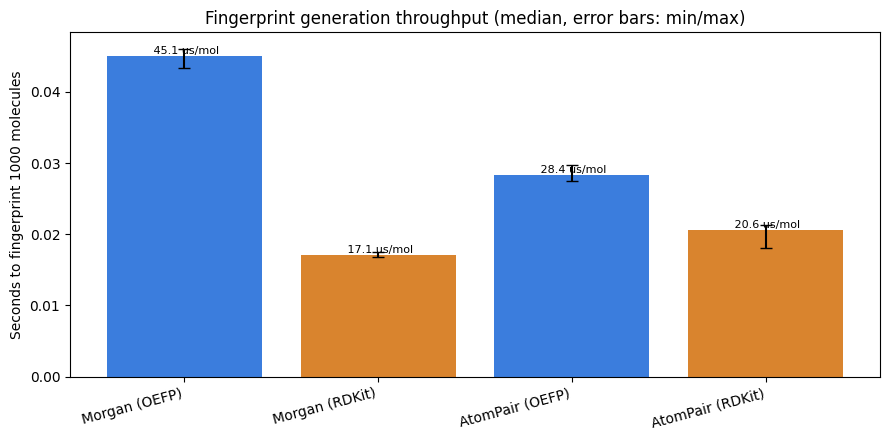

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))

labels = timings_df["label"].tolist()
positions = np.arange(len(labels))
medians = timings_df["median_s"].to_numpy()
# Error bars drawn from min/max to show worst-case dispersion.
mins = timings_df["min_s"].to_numpy()
maxs = timings_df["max_s"].to_numpy()
lower = medians - mins
upper = maxs - medians

colors = ["#3b7ddd" if "OEFP" in lbl else "#d9842e" for lbl in labels]
ax.bar(positions, medians, yerr=[lower, upper], color=colors, capsize=4)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel(f"Seconds to fingerprint {BENCH_N} molecules")
ax.set_title("Fingerprint generation throughput (median, error bars: min/max)")

for pos, row in zip(positions, timings_df.itertuples(index=False)):
    ax.text(pos, row.median_s, f" {row.per_mol_us:.1f} us/mol", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


#### Ratio table

The ratio column is ``OEFP / RDKit`` — values below 1.0 mean OEFP is faster.


In [12]:
ratio_rows = []
for kind in ("Morgan", "AtomPair"):
    oe = timings_df.loc[timings_df.label == f"{kind} (OEFP)", "median_s"].iloc[0]
    rd = timings_df.loc[timings_df.label == f"{kind} (RDKit)", "median_s"].iloc[0]
    ratio_rows.append({
        "fingerprint": kind,
        "oefp_s": oe,
        "rdkit_s": rd,
        "oefp_over_rdkit": oe / rd,
        "rdkit_over_oefp": rd / oe,
    })
pd.DataFrame(ratio_rows)


,fingerprint,oefp_s,rdkit_s,oefp_over_rdkit,rdkit_over_oefp
0,Morgan,0.045079,0.017082,2.638906,0.378945
1,AtomPair,0.028385,0.020643,1.375050,0.727246


### 3.3 Pairwise distance kernel (``pdist``)

For the batch pairwise workload, OEFP exposes a native ``pdist`` kernel that
packs the dense-binary fingerprints contiguously and computes all
``n * (n - 1) / 2`` distances in a single call. The RDKit equivalent is
``BulkTanimotoSimilarity`` in a Python loop (the canonical vectorized path for
``ExplicitBitVect`` objects from ``rdFingerprintGenerator``).

We keep the same fingerprints generated in section 3.2 so this is an
apples-to-apples comparison of the kernels themselves.


In [13]:
PDIST_N = min(400, BENCH_N)
oe_pdist_fps = [
    oefp.morgan_fingerprint(OE_MOLS[i], radius=MORGAN_RADIUS, num_bits=MORGAN_NBITS)
    for i in range(PDIST_N)
]
rd_pdist_fps = [
    rd_morgan_gen.GetFingerprint(RD_MOLS[i]) for i in range(PDIST_N)
]

oe_pdist_batch = oefp.OEFPBatch.from_fingerprints(oe_pdist_fps)
metric = oefp.Metric.tanimoto()


def run_oe_pdist() -> np.ndarray:
    return oefp.pdist(oe_pdist_batch, metric, num_threads=0, chunk_size=256)


def run_rd_pdist() -> np.ndarray:
    n = len(rd_pdist_fps)
    out = np.empty(n * (n - 1) // 2, dtype=np.float64)
    k = 0
    for i in range(n - 1):
        row = DataStructs.BulkTanimotoSimilarity(rd_pdist_fps[i], rd_pdist_fps[i + 1:])
        length = len(row)
        out[k:k + length] = row
        k += length
    return out


oe_pdist_stats = time_trials(run_oe_pdist, trials=TRIALS)
oe_pdist_stats.label = "pdist (OEFP)"
rd_pdist_stats = time_trials(run_rd_pdist, trials=TRIALS)
rd_pdist_stats.label = "pdist (RDKit BulkTanimoto)"

pdist_rows = [oe_pdist_stats.as_row(), rd_pdist_stats.as_row()]
pdist_df = pd.DataFrame(pdist_rows)
pdist_df["pairs"] = PDIST_N * (PDIST_N - 1) // 2
pdist_df["ns_per_pair"] = pdist_df["median_s"] / pdist_df["pairs"] * 1e9
pdist_df


,label,median_s,iqr_s,min_s,max_s,n_trials,pairs,ns_per_pair
0,pdist (OEFP),0.000272,0.000077,0.000241,0.000379,7,79800,3.407995
1,pdist (RDKit BulkTanimoto),0.012539,0.000211,0.011420,0.012800,7,79800,157.136065


In [14]:
# Sanity-check numerical parity of the two kernels on the condensed output.
oe_values = run_oe_pdist()
rd_values = run_rd_pdist()

pdist_parity = {
    "n_pairs": int(oe_values.size),
    "mean_abs_diff": float(np.abs(oe_values - rd_values).mean()),
    "max_abs_diff": float(np.abs(oe_values - rd_values).max()),
    "pearson_r": float(np.corrcoef(oe_values, rd_values)[0, 1]),
}
pd.Series(pdist_parity, name="morgan_pdist_parity").to_frame()


,morgan_pdist_parity
n_pairs,79800.0
mean_abs_diff,0.0
max_abs_diff,0.0
pearson_r,1.0


### 3.4 Trial-level dispersion

A median + IQR tells us the central tendency, but scanning the raw trial
samples makes it easier to spot GC spikes, thermal throttling, or genuinely
bimodal distributions. This cell records individual samples for the key
workloads and shows them as a strip plot.


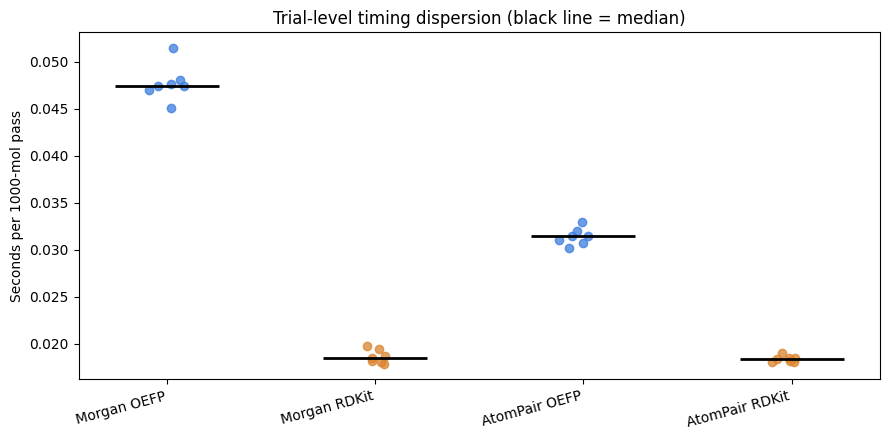

,label,median_s,std_s,cv,min_s,max_s
0,Morgan OEFP,0.047429,0.001912,0.040050,0.045042,0.051453
1,Morgan RDKit,0.018463,0.000711,0.038128,0.017904,0.019733
2,AtomPair OEFP,0.031471,0.000902,0.028722,0.030163,0.032949
3,AtomPair RDKit,0.018409,0.000334,0.018165,0.018100,0.019055


In [15]:
raw_samples: dict[str, list[float]] = {}
for label, fn in [
    ("Morgan OEFP", oe_morgan_call),
    ("Morgan RDKit", rd_morgan_call),
    ("AtomPair OEFP", oe_ap_call),
    ("AtomPair RDKit", rd_ap_call),
]:
    # One warmup, then TRIALS samples.
    fn()
    samples = []
    for _ in range(TRIALS):
        start = time.perf_counter()
        fn()
        samples.append(time.perf_counter() - start)
    raw_samples[label] = samples

fig, ax = plt.subplots(figsize=(9, 4.5))
positions = np.arange(len(raw_samples))
for i, (label, samples) in enumerate(raw_samples.items()):
    jitter = rng.normal(0, 0.05, size=len(samples))
    ax.scatter(
        np.full(len(samples), i) + jitter,
        samples,
        alpha=0.75,
        color="#3b7ddd" if "OEFP" in label else "#d9842e",
    )
    ax.hlines(statistics.median(samples), i - 0.25, i + 0.25, color="black", linewidth=2)

ax.set_xticks(positions)
ax.set_xticklabels(list(raw_samples.keys()), rotation=15, ha="right")
ax.set_ylabel(f"Seconds per {BENCH_N}-mol pass")
ax.set_title("Trial-level timing dispersion (black line = median)")
plt.tight_layout()
plt.show()

dispersion_rows = []
for label, samples in raw_samples.items():
    arr = np.asarray(samples)
    dispersion_rows.append({
        "label": label,
        "median_s": float(np.median(arr)),
        "std_s": float(arr.std(ddof=1)),
        "cv": float(arr.std(ddof=1) / arr.mean()) if arr.mean() else float("nan"),
        "min_s": float(arr.min()),
        "max_s": float(arr.max()),
    })
pd.DataFrame(dispersion_rows)


## 4. Summary

In [16]:
summary_lines = [
    f"Dataset: NCI first_5K.smi (n={len(SMILES)} parsed by both toolkits).",
    "",
    "Parity:",
    f"  Morgan folded binary — exact match rate: {morgan_summary['exact_match_rate']:.4f}, "
    f"mean Jaccard: {morgan_summary['mean_jaccard']:.4f}, "
    f"max |popcount delta|: {morgan_summary['max_abs_popcount_delta']}.",
    f"  Atom Pair folded binary — exact match rate: {ap_summary['exact_match_rate']:.4f}, "
    f"mean Jaccard: {ap_summary['mean_jaccard']:.4f}.",
    f"  Morgan Tanimoto similarity distribution — mean |delta|: {sim_summary['mean_abs_diff']:.2e}, "
    f"Pearson r: {sim_summary['pearson_r']:.6f}.",
    "",
    "Performance (median seconds over "
    f"{BENCH_N} molecules, {TRIALS} trials):",
]

for row in timings:
    summary_lines.append(
        f"  {row['label']:<20} median={row['median_s']:.3f}s  "
        f"per_mol={row['per_mol_us']:.1f}us"
    )

summary_lines.append("")
summary_lines.append("pdist kernel (Morgan, n={})".format(PDIST_N))
for row in pdist_rows:
    summary_lines.append(
        f"  {row['label']:<32} median={row['median_s']:.3f}s"
    )

print("\n".join(summary_lines))


Dataset: NCI first_5K.smi (n=1500 parsed by both toolkits).

Parity:
  Morgan folded binary — exact match rate: 0.9993, mean Jaccard: 0.9999, max |popcount delta|: 1.
  Atom Pair folded binary — exact match rate: 0.9987, mean Jaccard: 0.9998.
  Morgan Tanimoto similarity distribution — mean |delta|: 1.69e-05, Pearson r: 0.999976.

Performance (median seconds over 1000 molecules, 7 trials):
  Morgan (OEFP)        median=0.045s  per_mol=45.1us
  Morgan (RDKit)       median=0.017s  per_mol=17.1us
  AtomPair (OEFP)      median=0.028s  per_mol=28.4us
  AtomPair (RDKit)     median=0.021s  per_mol=20.6us

pdist kernel (Morgan, n=400)
  pdist (OEFP)                     median=0.000s
  pdist (RDKit BulkTanimoto)       median=0.013s
